In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


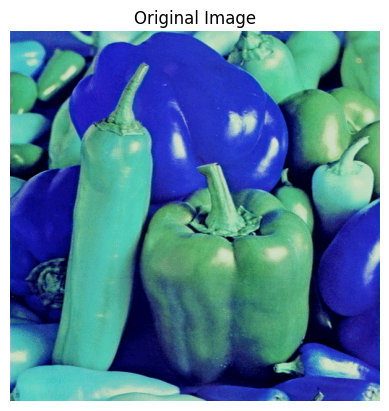

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
img = cv2.imread("drive/MyDrive/CV Images/peppers_color.tif")
img = np.asarray(img).astype(np.float32)
plt.imshow(img.astype(np.uint8))
plt.title('Original Image')
plt.axis('off')
plt.show()

pixels = img.reshape(-1, 3).astype(float)

In [7]:
def multivariate_gaussian(X, mu, sigma):
    n, d = X.shape
    det = np.linalg.det(sigma)
    if det == 0:
        sigma += 1e-6 * np.eye(d)
        det = np.linalg.det(sigma)
    inv = np.linalg.inv(sigma)
    norm_const = 1.0 / (np.power(2 * np.pi, d / 2) * np.sqrt(det))
    exponent = -0.5 * np.sum(np.dot(X-mu, inv) * (X-mu), axis=1)
    return norm_const * np.exp(exponent)

def em_gmm_algo(X, k, max_iter=50, tol=1e-4):
    n, d = X.shape
    indices = np.random.choice(n, k, replace=False)
    means = X[indices]
    covs = [np.eye(d) * 10 for _ in range(k)]
    weights = np.ones(k) / k
    log_likelihood = 0
    
    for i in range(max_iter):
        responsibilities = np.zeros((n, k))
        for j in range(k):
            responsibilities[:, j] = weights[j] * multivariate_gaussian(X, means[j], covs[j])
        
        sum_resp = np.sum(responsibilities, axis=1, keepdims=True)
        sum_resp[sum_resp == 0] = 1e-10
        responsibilities /= sum_resp
        
        N_k = np.sum(responsibilities, axis=0)
        weights = N_k / n
        means = np.zeros((k, d))

        for j in range(k):
            means[j] = np.sum(responsibilities[:, j].reshape(-1, 1) * X, axis=0) / N_k[j]
            
        for j in range(k):
            diff = X - means[j]
            weighted_diff = (responsibilities[:, j].reshape(-1, 1)) * diff
            covs[j] = np.dot(weighted_diff.T, diff) / N_k[j]
            covs[j] += 1e-6 * np.eye(d)

        current_log_likelihood = np.sum(np.log(sum_resp))
        if i > 0 and abs(current_log_likelihood - log_likelihood) < tol:
            print(f"Convergence at iteration {i}")
            break
        log_likelihood = current_log_likelihood
        print(f"Iteration {i}, Log-Likelihood: {log_likelihood:.4f}")

    return means, covs, weights, responsibilities

Segmenting the image with K = 5 clusters based on color features..

EM for K=5 clusters...
Iteration 0, Log-Likelihood: -35776054.1118
Iteration 1, Log-Likelihood: -3723698.5706
Iteration 2, Log-Likelihood: -3711309.4854
Iteration 3, Log-Likelihood: -3699539.9977
Iteration 4, Log-Likelihood: -3687456.1636
Iteration 5, Log-Likelihood: -3672305.8738
Iteration 6, Log-Likelihood: -3666051.1384
Iteration 7, Log-Likelihood: -3662444.0439
Iteration 8, Log-Likelihood: -3660024.4385
Iteration 9, Log-Likelihood: -3658516.8985
Iteration 10, Log-Likelihood: -3657589.7536
Iteration 11, Log-Likelihood: -3657040.2856
Iteration 12, Log-Likelihood: -3656626.4307
Iteration 13, Log-Likelihood: -3656248.3060
Iteration 14, Log-Likelihood: -3655851.7392
Iteration 15, Log-Likelihood: -3655402.8121
Iteration 16, Log-Likelihood: -3654907.0927
Iteration 17, Log-Likelihood: -3654324.1563
Iteration 18, Log-Likelihood: -3653328.1616
Iteration 19, Log-Likelihood: -3652197.7273
Iteration 20, Log-Likelihood: -3650390.4139
Iteration 21, Log-Likelihood: -3647025.7052
Iteration 22, Log-

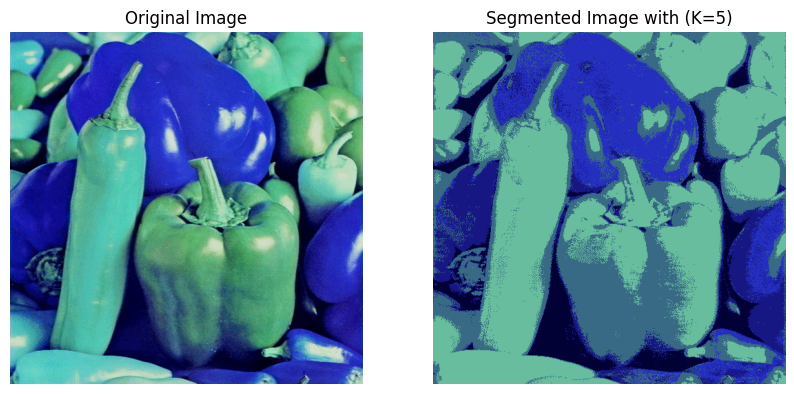

In [8]:

K = 5 
print(f"EM for K={K} clusters...")
final_means, final_covs, final_weights, responsibilities = em_gmm_algo(pixels, K, max_iter=30)

labels = np.argmax(responsibilities, axis=1)
segmented_pixels = final_means[labels]
segmented_img = segmented_pixels.reshape(img.shape).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img.astype(np.uint8))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_img)
plt.title(f'Segmented Image with (K={K})')
plt.axis('off')
plt.show()

## Segmentation results

With K=5, the GMM is able to separate the image into major color-intensity regions and preserves  the main pepper shapes, shadow regions and the scene structure is recognizable. However, the segmentation is coarse rather than precise i.e. some parts of the same pepper are split into different clusters because of lighting condition and shading, and some regions appear speckled because the model uses only RGB color features and no spatial information. Also similar shades are merged together, so the image looks cleaner and more abstract than the original so the model is successfully grouping pixels with similar RGB values into the same segment. 